<a href="https://colab.research.google.com/github/jrodriguezrosales/FOR606-GEOESTADISTICA/blob/main/Simulacion_Trigo_N.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colegio de Postgraduados
## Campus Montecillo
### POSGRADO EN HIDROCIENCIAS

**Curso:** HID624: Modelos de Simulación Aplicados a la Agricultura

**Titular del curso:** Dr. Carlos Alberto Ortiz Solorio

## Simulación del modelo de trigo (HID624) — con submodelo de Nitrógeno

**Presenta:** José Rodríguez Rosales

Montecillo, Texcoco, México, 2026

Este notebook lee la plantilla `Plantilla_Modelo_Trigo:N.xlsx` (hojas **Parametros**, **Periodos**, **Particion** y la nueva hoja **Nitrogeno**) y ejecuta:

1. El modelo de crecimiento y balance hídrico original (sin cambios en su lógica).
2. Un **submodelo de nitrógeno en planta** (adaptado del `NonLegumPlantN` de Soltani & Sinclair, 2012), acoplado como un factor de suficiencia que reduce `DMI` — igual que el agua reduce `GASS` vía `T_real/Tm`.
3. Un **submodelo de nitrógeno en el suelo**

## Qué cambió y por qué

**No es una traducción línea por línea del libro.** El mecanismo de Soltani reduce el área foliar vía la concentración de N en la hoja (`SLN`), variable que el modelo de excel no tiene (el modelo reparte biomasa por decena con `FR/FL/FS/FG`, no día a día con IAF/SLN). Reducir `DMI` directamente con un `FactorN` es la forma más honesta de acoplar N sin inventar una mecánica de SLN que tu estructura no soporta.

El modelo avanza por decenas (periodos de ~10 días), no día a día. Comparar `DAP == día_exacto` contra el `DAP` acumulado al cierre de cada periodo casi nunca coincide. Ahora se revisa si el día de aplicación cae **dentro del rango del periodo** (`DAP_inicio < día_aplicación <= DAP_fin`).

`MXNUP` es una tasa **diaria** (g N/m²/día, así la define el libro). Se estaba usando como tope de todo el periodo de 10 días, es decir, 10 veces más restrictivo de lo debido. Ahora la oferta máxima del periodo es `MXNUP * ND`.

El modelo mueve biomasa en `kg/ha`; el submodelo de N (tomado del libro) trabaja en `g/m²`. La conversión es `1 kg/ha = 0.1 g/m²` (1000 g / 10 000 m²). Todo incremento de biomasa (`IWLV`, `IWST`, `IWGR`) se convierte a `g/m²` **antes** de multiplicarlo por una concentración de N, y `IWLV`/`IWST` en tu modelo son incrementos de **masa** de hoja/tallo (no de área), que es justo lo que la demanda de N necesita (crecimiento de tejido × concentración de N del tejido).

El libro retransloca N entre hoja, tallo y grano día a día (`XNLF`, `XNST`) porque necesita sostener la concentración foliar (`SLN`) que regula el área. Como el modelo no tiene esa variable, aquí el N absorbido cada periodo se reparte proporcionalmente entre la demanda vegetativa (hoja+tallo) y la demanda de grano — sin retraslocación fina entre órganos. El grano **no se limita directamente por N** (solo indirectamente porque todo el `DMI` del periodo se reduce con `FactorN`, igual que en el libro el carbono limita al grano y el N solo entra por la vía indirecta del área foliar).

In [1]:
# Importar librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 1. Sube la plantilla llena

Ejecuta la celda siguiente y selecciona el archivo `Plantilla_Modelo_Trigo_N.xlsx` ya llenado (incluye la nueva hoja **Nitrogeno**, opcional). Si no estás en Colab, cambia la ruta manualmente en la variable `ruta_archivo`.

In [2]:
try:
    from google.colab import files
    subido = files.upload()
    ruta_archivo = list(subido.keys())[0]
except ImportError:
    # No estamos en Colab: ajusta esta ruta a tu archivo local
    ruta_archivo = "Plantilla_Modelo_Trigo.xlsx"

print("Archivo a usar:", ruta_archivo)


Saving Plantilla_Modelo_Trigo_N.xlsx to Plantilla_Modelo_Trigo_N.xlsx
Archivo a usar: Plantilla_Modelo_Trigo_N.xlsx


## 2. Leer parámetros generales, periodos y tabla de partición (sin cambios)

In [3]:
hoja_param = pd.read_excel(ruta_archivo, sheet_name="Parametros", header=None)
hoja_param = hoja_param.dropna(subset=[2])  # columna C = valores (index 2, 0-based)

def valor_parametro(nombre_contiene, hoja=None):
    hoja = hoja_param if hoja is None else hoja
    fila = hoja[hoja[1].astype(str).str.contains(nombre_contiene, case=False, na=False, regex=False)]
    if len(fila) == 0:
        raise ValueError(f"No se encontro el parametro que contiene: '{nombre_contiene}'")
    return float(fila.iloc[0, 2])

parametros = {
    "CC":        valor_parametro("Capacidad de campo"),
    "PMP":       valor_parametro("marchitez permanente"),
    "WRT0":      valor_parametro("WRT0"),
    "WLV0":      valor_parametro("WLV0"),
    "UT01":      valor_parametro("emergencia-floración"),
    "AFE":       valor_parametro("específica"),
    "TasaSen":   valor_parametro("senescencia autónoma"),
    "Rdin":      valor_parametro("Rdin"),
    "Rdmax":     valor_parametro("Rdmax"),
    "TasaCD":    valor_parametro("crecimiento radicular"),
    "SMnr":      valor_parametro("no radicular"),
    "Sma":       valor_parametro("franja segura"),
    "ke":        valor_parametro("extinción de luz"),
    "Rm":        valor_parametro("mantenimiento"),
    "Eg":        valor_parametro("vegetativa"),
    "Eg2":       valor_parametro("Eg2"),
    "FactorEstres": valor_parametro("Factor de estrés"),
    "PeriodoCambioEg": valor_parametro("Eg2 en vez de Eg"),
}
try:
    rendimiento_esperado = valor_parametro("Rendimiento esperado")
except ValueError:
    rendimiento_esperado = None

print("Parametros leidos:")
for k, v in parametros.items():
    print(f"  {k}: {v}")
print("Rendimiento esperado (referencia):", rendimiento_esperado)


Parametros leidos:
  CC: 0.225
  PMP: 0.09
  WRT0: 40.0
  WLV0: 50.0
  UT01: 2215.0
  AFE: 20.0
  TasaSen: -0.02
  Rdin: 100.0
  Rdmax: 1250.0
  TasaCD: 12.0
  SMnr: 0.1589
  Sma: 0.03
  ke: 0.6
  Rm: 0.015
  Eg: 0.7
  Eg2: 0.8
  FactorEstres: 0.03
  PeriodoCambioEg: 10.0
Rendimiento esperado (referencia): 6920.0


In [4]:
periodos = pd.read_excel(ruta_archivo, sheet_name="Periodos", header=4)
periodos = periodos.dropna(subset=["Periodo"]).reset_index(drop=True)
periodos.columns = [str(c).strip() for c in periodos.columns]
print(f"{len(periodos)} periodos leidos.")
periodos


13 periodos leidos.


,Unnamed: 0,Periodo,ND (días),Ta (°C),P (mm),Ie (mm),Fgs (kg/ha/d),ETo (mm/d),RA,Kc,p (agotamiento permisible)
0,NaN,1,10,17.0,0.0,40,315.43,3.56,0.0582,0.40,0.88
1,NaN,2,10,17.0,7.4,0,309.02,3.42,0.1296,0.40,0.80
2,NaN,3,10,17.0,0.0,85,312.97,3.47,0.2892,0.63,0.80
3,NaN,4,10,16.5,0.0,0,316.92,3.52,0.5269,0.87,0.80
4,NaN,5,10,16.5,11.0,0,320.88,3.57,0.7431,1.10,0.80
5,NaN,6,10,16.5,0.0,85,336.16,3.84,0.8669,1.10,0.80
6,NaN,7,10,18.2,0.0,0,351.45,4.12,0.9199,1.10,0.74
7,NaN,8,10,18.2,7.3,0,366.73,4.39,0.9361,1.10,0.74
8,NaN,9,10,18.2,0.0,95,382.36,4.73,0.9379,1.10,0.67
9,NaN,10,10,20.7,0.0,0,397.99,5.07,0.9263,1.10,0.71


In [5]:
particion = pd.read_excel(ruta_archivo, sheet_name="Particion", header=4)
particion = particion.dropna(subset=["EMD (DVS)"]).reset_index(drop=True)
particion.columns = [str(c).strip() for c in particion.columns]
particion = particion.sort_values("EMD (DVS)").reset_index(drop=True)
particion


,Unnamed: 0,EMD (DVS),FR,FL,FS,FG
0,NaN,0.00,0.50,0.50,0.00,0
1,NaN,0.12,0.34,0.66,0.00,0
2,NaN,0.21,0.23,0.56,0.21,0
3,NaN,0.37,0.09,0.34,0.57,0
4,NaN,0.50,0.04,0.10,0.86,0
5,NaN,0.59,0.00,0.00,0.00,1
6,NaN,1.00,0.00,0.00,0.00,1


## 3. Nitrógeno — lectura de la hoja `Nitrogeno`

Si la hoja no existe en el archivo subido, la simulación corre exactamente igual que antes (sin limitación de N). Si existe, se leen:

- **Parámetros de planta**: `SNCG` (concentración N de crecimiento en hoja+tallo, g N/g MS), `SNCS` (concentración N estructural mínima en tallo), `GNC` (concentración N del grano) y `MXNUP` (tasa **máxima diaria** de absorción de N, g N/m²/día).
- **Parámetros de suelo**: espesor de capa (`DEP1`), fracción de gravas (`FG`), densidad aparente (`BD1`), N orgánico (`NORGP`), fracción mineralizable (`FMIN`) y concentraciones iniciales de NO3⁻/NH4⁺.
- **Tabla de aplicaciones de fertilizante**: hasta 10 filas de (día de aplicación en DAP, N aplicado en g N/m², % de volatilización).

In [6]:
def leer_parametros_n(ruta_archivo):
    """Lee la hoja Nitrogeno. Devuelve (None, []) si la hoja no existe -> sin N."""
    try:
        hoja = pd.read_excel(ruta_archivo, sheet_name="Nitrogeno", header=None)
    except ValueError:
        return None, []

    hoja_val = hoja.dropna(subset=[2])

    def buscar(nombre_contiene):
        fila = hoja_val[hoja_val[1].astype(str).str.contains(nombre_contiene, case=False, na=False, regex=False)]
        if len(fila) == 0:
            return None
        return float(fila.iloc[0, 2])

    p_n = {
        "SNCG":  buscar("SNCG"),
        "SNCS":  buscar("SNCS"),
        "GNC":   buscar("GNC"),
        "MXNUP": buscar("MXNUP"),
        "DEP1":  buscar("DEP1"),
        "FG":    buscar("FG"),
        "BD1":   buscar("BD1"),
        "NORGP": buscar("NORGP"),
        "FMIN":  buscar("FMIN"),
        "NO3":   buscar("NO3"),
        "NH4":   buscar("NH4"),
    }
    if any(v is None for v in p_n.values()):
        faltantes = [k for k, v in p_n.items() if v is None]
        raise ValueError(f"Faltan parametros de N en la hoja 'Nitrogeno': {faltantes}")

    # Tabla de fertilizaciones: localizar la fila de encabezado por su texto
    mask = hoja[1].astype(str).str.contains("DAP de aplicación", case=False, na=False)
    aplicaciones = []
    if mask.any():
        fila_header = mask[mask].index[0]
        tabla = hoja.iloc[fila_header + 1: fila_header + 11, [1, 2, 3]].copy()
        tabla.columns = ["DAP", "N_gm2", "VolPct"]
        tabla = tabla.dropna(subset=["DAP", "N_gm2"])
        for _, f in tabla.iterrows():
            volf = float(f["VolPct"]) if not pd.isna(f["VolPct"]) else 0.0
            aplicaciones.append((float(f["DAP"]), float(f["N_gm2"]), volf))
    return p_n, aplicaciones


parametros_n, aplicaciones_n = leer_parametros_n(ruta_archivo)
simular_nitrogeno = parametros_n is not None

if simular_nitrogeno:
    print("Hoja 'Nitrogeno' encontrada. Se simulará con limitación de N.")
    print("Parametros N:", parametros_n)
    print("Aplicaciones de fertilizante (DAP, gN/m2, %volatilizacion):", aplicaciones_n)
else:
    print("No se encontró la hoja 'Nitrogeno'. Se simulará sin limitación de N (comportamiento original).")


Hoja 'Nitrogeno' encontrada. Se simulará con limitación de N.
Parametros N: {'SNCG': 0.022, 'SNCS': 0.005, 'GNC': 0.0213, 'MXNUP': 0.25, 'DEP1': 600.0, 'FG': 0.0, 'BD1': 1.35, 'NORGP': 0.08, 'FMIN': 0.1, 'NO3': 15.0, 'NH4': 1.8}
Aplicaciones de fertilizante (DAP, gN/m2, %volatilizacion): [(1.0, 5.0, 5.0), (31.0, 5.0, 5.0), (61.0, 5.0, 5.0)]


## 4. Submodelo de N en el suelo


El N recién aplicado solo queda disponible para el periodo *siguiente*. En el libro eso no importa porque el paso es diario (desfase de 1 día); en tu modelo, con periodos de ~10 días, ese desfase es demasiado grande — una aplicación en siembra no estaría disponible sino hasta ~10 días después. Ahora `aplicar_fertilizante` se ejecuta primero y dentro del mismo periodo actualiza `SNAVL`, así que el submodelo de planta ya ve el N fertilizado disponible en ese mismo periodo.
- `actualizar_soil_n` ahora solo hace mineralización, lixiviación, desnitrificación y el descuento del `NUP` absorbido por la planta.


In [7]:
def inicializar_soil_n(p_n, WAT1_ini):
    FG = p_n["FG"] / 100.0
    BD1 = p_n["BD1"]
    NORGP = p_n["NORGP"]
    FMIN = p_n["FMIN"]
    NO3_ppm = p_n["NO3"]
    NH4_ppm = p_n["NH4"]
    DEP1 = p_n["DEP1"]

    # Masa de suelo en la capa superficial (g/m2)
    SOILM = DEP1 * BD1 * (1 - FG) * 1000
    NORG = NORGP * 0.01 * SOILM
    MNORG = NORG * FMIN

    # ppm -> gN/m2
    NO3 = NO3_ppm * (14 / 62) * 0.000001 * SOILM
    NH4 = NH4_ppm * (14 / 18) * 0.000001 * SOILM
    NSOL = NO3 + NH4
    NCON = NSOL / (WAT1_ini * 1000) if WAT1_ini > 0 else 0.0

    return {
        "MNORG": MNORG, "NSOL": NSOL, "NCON": NCON,
        "CNFERT": 0.0, "CNVOL": 0.0, "CNLEACH": 0.0, "CNMIN": 0.0, "CNDNIT": 0.0,
        "SNAVL": 0.0,
    }


def aplicar_fertilizante(estado_n, p_n, aplicaciones, DAP_ini, DAP_fin, WAT1, DEPORT):
    """Aplica el fertilizante que caiga dentro de (DAP_ini, DAP_fin] y deja el N
    disponible de inmediato para la demanda de planta de ESTE MISMO periodo.

    Antes, la fertilizacion se sumaba al final del periodo (junto con mineralizacion,
    lixiviacion, etc.), por lo que el N recien aplicado solo quedaba disponible para
    el periodo SIGUIENTE. Con periodos de ~10 dias ese desfase es demasiado grande
    (en el libro, con pasos diarios, el desfase es de un solo dia y no importa).
    Ahora la aplicacion se procesa primero, antes de calcular la demanda de N de
    la planta del periodo.
    """
    DEP1 = p_n["DEP1"]

    NFERT = 0.0
    NVOL = 0.0
    for dap_aplicacion, n_amt, vol_pct in aplicaciones:
        if DAP_ini < dap_aplicacion <= DAP_fin:
            NFERT += n_amt
            NVOL += (vol_pct / 100.0) * n_amt

    estado_n["CNFERT"] += NFERT
    estado_n["CNVOL"] += NVOL
    estado_n["NSOL"] = estado_n["NSOL"] + NFERT - NVOL
    estado_n["NCON"] = estado_n["NSOL"] / (WAT1 * 1000) if WAT1 > 0 else 0.0

    FROOT1 = min(DEPORT / DEP1, 1.0) if DEP1 > 0 else 1.0
    SNAVL = (estado_n["NCON"] - 0.000001) * WAT1 * 1000 * FROOT1
    estado_n["SNAVL"] = max(SNAVL, 0.0)
    return estado_n


def actualizar_soil_n(estado_n, p_n, TMP, FTSW1, WAT1, DRAIN1, NUP, DEPORT):
    """Mineralizacion, lixiviacion, desnitrificacion y descuento de la absorcion (NUP).
    La aplicacion de fertilizante YA NO se procesa aqui (ver aplicar_fertilizante),
    para que el N recien aplicado este disponible desde el mismo periodo."""
    DEP1 = p_n["DEP1"]

    # 1. Mineralizacion neta de N
    TMPS = min(TMP, 35.0)
    KNMIN = 24 * np.exp(17.753 - 6350.5 / (TMPS + 273)) / 168
    KN = 1 - np.exp(-KNMIN)
    RN = 1.111 * FTSW1 if FTSW1 < 0.9 else (10 - 10 * FTSW1)
    RN = max(RN, 0.0)
    NMIN = estado_n["MNORG"] * RN * KN
    NMIN = NMIN * (0.0002 - estado_n["NCON"]) / 0.0002  # umbral 200 mgN/L
    NMIN = max(NMIN, 0.0)
    estado_n["MNORG"] -= NMIN
    estado_n["CNMIN"] += NMIN

    # 2. Movimiento descendente de N (lixiviacion)
    NLEACH = 0.0
    if (WAT1 + DRAIN1) > 0:
        NLEACH = estado_n["NSOL"] * (DRAIN1 / (WAT1 + DRAIN1))
    if estado_n["NCON"] <= 0.000001:  # umbral 1 mgN/L
        NLEACH = 0.0
    estado_n["CNLEACH"] += NLEACH

    # 3. Desnitrificacion
    NDNIT = 0.0
    if FTSW1 > 1.0:
        XNCON = min(estado_n["NCON"], 0.0004)  # umbral 400 mgN/L
        KDNIT = 6 * np.exp(0.07735 * TMPS - 6.593)
        NDNIT = XNCON * (1 - np.exp(-KDNIT)) * WAT1 * 1000
    estado_n["CNDNIT"] += NDNIT

    # 4. Actualizacion del balance (incluye descuento del NUP absorbido por la planta)
    FROOT1 = min(DEPORT / DEP1, 1.0) if DEP1 > 0 else 1.0
    estado_n["NSOL"] = estado_n["NSOL"] + NMIN - NLEACH - NDNIT - NUP
    estado_n["NCON"] = estado_n["NSOL"] / (WAT1 * 1000) if WAT1 > 0 else 0.0
    SNAVL = (estado_n["NCON"] - 0.000001) * WAT1 * 1000 * FROOT1
    estado_n["SNAVL"] = max(SNAVL, 0.0)
    return estado_n

print("Submodelo de N en el suelo definido (fertilizacion separada, disponible el mismo periodo).")


Submodelo de N en el suelo definido (fertilizacion separada, disponible el mismo periodo).


## 5. Submodelo de N en planta (adaptado de `NonLegumPlantN`)

Cada periodo, **antes** de repartir `DMI` en `IWRT/IWLV/IWST/IWGR`:

1. Se estima la demanda de N a partir del crecimiento **potencial** (limitado solo por agua) de tejido vegetativo (`FL+FS`) y de grano (`FG`), convertido de `kg/ha` a `g/m²` (`× 0.1`).
2. La oferta de N del periodo es el mínimo entre la demanda, la tasa máxima (`MXNUP × ND`, con `ND` = días del periodo, ya no se aplica `MXNUP` como si fuera el tope del periodo completo) y el N disponible en el suelo (`SNAVL`, calculado al cierre del periodo anterior).
3. `FactorN = min(1, N_absorbido / N_demandado)` multiplica `DMI` — igual que el agua multiplica `GASS` vía `T_real/Tm`. Esto reduce el crecimiento (hoja, tallo **y** grano) de todo el periodo, no solo el grano; el grano no tiene un límite de N aparte del que ya trae `DMI` reducido, tal como en el libro el carbono es lo que limita el peso seco del grano.
4. El N efectivamente absorbido se reparte de forma proporcional entre la demanda vegetativa y la de grano, para reportar acumulados de N en tejido — es una simplificación consciente y declarada; no hay retranslocación fina hoja↔tallo↔grano día a día como en el libro (eso requeriría la variable `SLN` que tu modelo no tiene).

In [8]:
KGHA_A_GM2 = 0.1  # 1 kg/ha = 0.1 g/m2 (1000 g / 10 000 m2)

def factores_particion(emd, tabla):
    # Interpolacion lineal (con recorte en los extremos) sobre la tabla varietal,
    # equivalente a las formulas de interpolacion por tramos de Excel.
    x = tabla["EMD (DVS)"].values
    fr = np.interp(emd, x, tabla["FR"].values)
    fl = np.interp(emd, x, tabla["FL"].values)
    fs = np.interp(emd, x, tabla["FS"].values)
    fg = np.interp(emd, x, tabla["FG"].values)
    return fr, fl, fs, fg


def submodelo_n_planta(DMI_potencial, FL, FS, FG, ND, p_n, SNAVL_disponible):
    """Devuelve (DMI_final, FactorN, NUP, demanda_total, demanda_veg, demanda_grano).

    DMI_potencial: kg/ha/dia, ya limitado por agua, previo a la reduccion por N.
    SNAVL_disponible: N disponible en el suelo (g/m2), calculado al cierre del periodo anterior.
    """
    crecimiento_veg_gm2   = DMI_potencial * (FL + FS) * ND * KGHA_A_GM2
    crecimiento_grano_gm2 = DMI_potencial * FG * ND * KGHA_A_GM2

    demanda_veg = crecimiento_veg_gm2 * p_n["SNCG"]
    demanda_grano = crecimiento_grano_gm2 * p_n["GNC"]
    demanda_total = demanda_veg + demanda_grano

    oferta_tasa_periodo = p_n["MXNUP"] * ND  # BUG CORREGIDO: tasa diaria x dias del periodo
    NUP = max(0.0, min(demanda_total, oferta_tasa_periodo, SNAVL_disponible))

    FactorN = 1.0 if demanda_total <= 0 else min(1.0, NUP / demanda_total)
    DMI_final = DMI_potencial * FactorN

    return DMI_final, FactorN, NUP, demanda_total, demanda_veg, demanda_grano

print("Submodelo de N en planta definido.")


Submodelo de N en planta definido.


## 6. Motor de simulación (agua + N acoplados)

In [9]:
def simular(periodos, parametros, particion, rendimiento_esperado=None,
            simular_nitrogeno=False, parametros_n=None, aplicaciones_n=None):
    p = parametros

    # ---- Condiciones iniciales (equivalentes a la fila 0 de excel) ----
    RD = p["Rdin"]
    Wr = RD * p["CC"]
    SMr = p["CC"]
    Wnr = p["SMnr"] * (p["Rdmax"] - p["Rdin"])
    WRT = p["WRT0"]
    WLV = p["WLV0"]
    WST = 0.0
    WGRN = 0.0
    TADW = WLV
    TDW = TADW + WRT
    TDWL = TDW
    TDWD = 0.0
    TSUM = 0.0
    DVS = 0.0
    IAF = WLV * p["AFE"] / 10000.0

    DAP = 0  # dias acumulados desde la siembra

    if simular_nitrogeno:
        DEP1_fijo = parametros_n["DEP1"]
        WAT1_ini = p["CC"] * DEP1_fijo
        estado_n = inicializar_soil_n(parametros_n, WAT1_ini)
        NVEG_acum = 0.0
        NGRN_acum = 0.0
        CNUP_acum = 0.0

    registros = []

    for _, fila in periodos.iterrows():
        ND = float(fila["ND (días)"])
        DAP_ini = DAP
        DAP += ND
        DAP_fin = DAP

        Ta = float(fila["Ta (°C)"])
        P_ = float(fila["P (mm)"])
        Ie = float(fila["Ie (mm)"])
        Fgs = float(fila["Fgs (kg/ha/d)"])
        ETo = float(fila["ETo (mm/d)"])
        RA = float(fila.get("RA", np.nan))
        pfrac = float(fila["p (agotamiento permisible)"])

        # ---- Fenologia ----
        TSUM_prev, DVS_prev = TSUM, DVS
        TSUM = TSUM_prev + ND * Ta
        DVS = TSUM / p["UT01"]
        EMD = (DVS_prev + DVS) / 2.0

        # ---- Fotosintesis potencial ----
        fh = 1 - np.exp(-p["ke"] * IAF)
        PGASS = Fgs * fh

        # ---- Profundidad de raiz ----
        RD_prev = RD
        RD = RD_prev + p["TasaCD"] * ND

        # ---- Balance hidrico ----
        IM = (P_ + Ie) / ND
        Em = ETo * (1 - RA)
        Ea = min(Em, Em * ((SMr - p["Sma"]) / (p["CC"] - p["Sma"])))
        Tm = ETo * RA
        SMcr = p["PMP"] + (1 - pfrac) * (p["CC"] - p["PMP"])
        if SMr > SMcr:
            T_real = Tm
        else:
            T_real = max(0.0, Tm * ((SMr - p["PMP"]) / (SMcr - p["PMP"])))

        if RD > p["Rdmax"]:
            dMr = 0.0
        else:
            dMr = Wnr * p["TasaCD"] / (p["Rdmax"] - RD_prev) if (p["Rdmax"] - RD_prev) > 0 else 0.0
        dWr = IM + dMr - Ea - T_real
        Wr = Wr + dWr * ND
        SMr = Wr / RD
        Wnr = Wnr - dMr * ND

        # ---- Aproximaciones para el balance de N (capa superficial) ----
        DEP1 = 600.0
        FTSW1 = (SMr - p["PMP"]) / (p["CC"] - p["PMP"])
        FTSW1 = max(0.0, min(1.0, FTSW1))
        WAT1 = SMr * DEP1
        SMr_temp = Wr / RD
        if SMr_temp > p["CC"]:
            DRAIN1 = (SMr_temp - p["CC"]) * RD
            Wr = p["CC"] * RD
        else:
            DRAIN1 = 0.0
        SMr = Wr / RD

        # ---- Produccion potencial y particion de materia seca ----
        GASS = PGASS * (T_real / Tm) if Tm > 0 else 0.0
        MRES = p["Rm"] * TDWL
        ASAG = max(0.0, GASS - MRES)
        Eg_usar = p["Eg"] if fila["Periodo"] < p["PeriodoCambioEg"] else p["Eg2"]
        DMI = ASAG * Eg_usar  # DMI potencial, limitado solo por agua

        FR, FL, FS, FG = factores_particion(EMD, particion)

        # ---- Submodelo de N: se fertiliza PRIMERO (para que el N este disponible
        # ---- este mismo periodo), y luego se reduce DMI con FactorN ----
        FactorN = 1.0
        NUP = 0.0
        demanda_total = 0.0
        if simular_nitrogeno:
            estado_n = aplicar_fertilizante(
                estado_n=estado_n, p_n=parametros_n, aplicaciones=aplicaciones_n,
                DAP_ini=DAP_ini, DAP_fin=DAP_fin, WAT1=WAT1, DEPORT=RD,
            )
            DMI, FactorN, NUP, demanda_total, demanda_veg, demanda_grano = submodelo_n_planta(
                DMI_potencial=DMI, FL=FL, FS=FS, FG=FG, ND=ND,
                p_n=parametros_n, SNAVL_disponible=estado_n["SNAVL"],
            )
            if demanda_total > 0:
                NVEG_acum += NUP * (demanda_veg / demanda_total)
                NGRN_acum += NUP * (demanda_grano / demanda_total)
            CNUP_acum += NUP

        IWRT = DMI * FR
        WRT = WRT + IWRT * ND

        IWLV = DMI * FL
        DWLV = p["FactorEstres"] * (1 - (T_real / Tm)) * WLV if Tm > 0 else 0.0
        WLV = WLV + (IWLV - DWLV) * ND
        if WLV < 0:
            WLV = 0.0

        IWST = DMI * FS
        WST = WST + IWST * ND

        IWGR = DMI * FG
        WGRN = WGRN + IWGR * ND

        IAF = WLV * p["AFE"] / 10000.0
        TADW = WLV + WST + WGRN
        TDW = TADW + WRT
        TDWL = TDW + (IWLV * ND) if EMD >= 1 else TDW
        TDWD = TDWD + DWLV * ND

        # ---- Submodelo de N en el suelo: se corre AL FINAL, con el NUP ya definido ----
        if simular_nitrogeno:
            estado_n = actualizar_soil_n(
                estado_n=estado_n, p_n=parametros_n, TMP=Ta, FTSW1=FTSW1,
                WAT1=WAT1, DRAIN1=DRAIN1, NUP=NUP, DEPORT=RD,
            )

        reg = {
            "Periodo": fila["Periodo"], "EMD": EMD, "SMr": SMr, "SMcr": SMcr,
            "T_real": T_real, "Tm": Tm, "IAF": IAF, "WLV": WLV, "WST": WST,
            "WRT": WRT, "WGRN": WGRN, "TADW": TADW, "TDW": TDW, "TDWD": TDWD,
        }
        if simular_nitrogeno:
            reg.update({
                "FactorN": FactorN,
                "N_demanda_gm2": demanda_total,
                "N_absorbido_gm2": NUP,
                "N_disponible_suelo_gm2": estado_n["SNAVL"],
                "N_lixiviado_acum_gm2": estado_n["CNLEACH"],
                "N_veg_acum_gm2": NVEG_acum,
                "N_grano_acum_gm2": NGRN_acum,
                "N_absorbido_acum_gm2": CNUP_acum,
            })
        registros.append(reg)

    salida = pd.DataFrame(registros)
    for col in salida.columns:
        if salida[col].dtype in ["float64", "float32"]:
            salida[col] = salida[col].round(3)

    rendimiento_obtenido = WGRN
    resumen = {"rendimiento_obtenido_kg_ha": rendimiento_obtenido}
    if rendimiento_esperado is not None:
        resumen["rendimiento_esperado_kg_ha"] = rendimiento_esperado
        resumen["diferencia_kg_ha"] = rendimiento_esperado - rendimiento_obtenido
        resumen["error_relativo_pct"] = 100 * (rendimiento_esperado - rendimiento_obtenido) / rendimiento_esperado

    return salida, resumen

print("Motor del modelo definido (agua + N acoplados).")


Motor del modelo definido (agua + N acoplados).


## 7. Correr la simulación

Corre primero **sin** N para confirmar que el resultado es idéntico al que ya tenías (control de no-regresión), y después **con** N si llenaste la hoja `Nitrogeno`.

In [10]:
salida_sin_n, resumen_sin_n = simular(periodos, parametros, particion, rendimiento_esperado)

print("----- Resultado SIN limitación de N (igual al modelo original) -----")
for k, v in resumen_sin_n.items():
    print(f"{k}: {v:,.2f}")

salida_sin_n


----- Resultado SIN limitación de N (igual al modelo original) -----
rendimiento_obtenido_kg_ha: 6,323.37
rendimiento_esperado_kg_ha: 6,920.00
diferencia_kg_ha: 596.63
error_relativo_pct: 8.62


,Periodo,EMD,SMr,SMcr,T_real,Tm,IAF,WLV,WST,WRT,WGRN,TADW,TDW,TDWD
0,1.0,0.038,0.209,0.106,0.207,0.207,0.231,115.663,0.000,93.472,0.000,115.663,209.134,0.000
1,2.0,0.115,0.120,0.117,0.443,0.443,0.569,284.508,0.000,182.997,0.000,284.508,467.505,0.000
2,3.0,0.192,0.225,0.117,1.004,1.004,1.247,623.634,98.034,330.397,0.000,721.668,1052.064,0.000
3,4.0,0.267,0.151,0.117,1.855,1.855,2.265,1132.637,457.193,520.572,0.000,1589.830,2110.402,0.000
4,5.0,0.342,0.122,0.117,2.653,2.653,3.361,1680.574,1191.075,686.337,0.000,2871.649,3557.987,0.000
5,6.0,0.416,0.187,0.117,3.329,3.329,4.208,2104.148,2313.661,806.520,0.000,4417.809,5224.329,0.000
6,7.0,0.495,0.141,0.125,3.790,3.790,4.584,2292.046,3768.389,878.529,0.000,6060.435,6938.964,0.000
7,8.0,0.577,0.109,0.125,4.109,4.109,4.633,2316.279,3976.794,888.223,1432.152,7725.225,8613.448,0.000
8,9.0,0.659,0.178,0.135,1.916,4.436,3.843,1921.522,3976.794,888.223,1612.001,7510.317,8398.539,394.758
9,10.0,0.747,0.123,0.129,4.696,4.696,3.843,1921.522,3976.794,888.223,3470.734,9369.050,10257.273,394.758


In [11]:
if simular_nitrogeno:
    salida, resumen = simular(periodos, parametros, particion, rendimiento_esperado,
                               simular_nitrogeno=True, parametros_n=parametros_n, aplicaciones_n=aplicaciones_n)
    print("----- Resultado CON limitación de N -----")
    for k, v in resumen.items():
        print(f"{k}: {v:,.2f}")
else:
    salida, resumen = salida_sin_n, resumen_sin_n
    print("No hay hoja 'Nitrogeno': se usa el resultado sin N para el resto del notebook.")

salida


----- Resultado CON limitación de N -----
rendimiento_obtenido_kg_ha: 3,006.37
rendimiento_esperado_kg_ha: 6,920.00
diferencia_kg_ha: 3,913.63
error_relativo_pct: 56.56


,Periodo,EMD,SMr,SMcr,T_real,Tm,IAF,WLV,WST,WRT,...,TDW,TDWD,FactorN,N_demanda_gm2,N_absorbido_gm2,N_disponible_suelo_gm2,N_lixiviado_acum_gm2,N_veg_acum_gm2,N_grano_acum_gm2,N_absorbido_acum_gm2
0,1.0,0.038,0.209,0.106,0.207,0.207,0.231,115.663,0.000,93.472,...,209.134,0.000,1.000,0.144,0.144,3.099,0.000,0.144,0.000,0.144
1,2.0,0.115,0.120,0.117,0.443,0.443,0.569,284.508,0.000,182.997,...,467.505,0.000,1.000,0.371,0.371,4.617,0.000,0.516,0.000,0.516
2,3.0,0.192,0.225,0.117,1.004,1.004,1.247,623.634,98.034,330.397,...,1052.064,0.000,1.000,0.962,0.962,4.748,0.904,1.478,0.000,1.478
3,4.0,0.267,0.151,0.117,1.855,1.855,2.265,1132.637,457.193,520.572,...,2110.402,0.000,1.000,1.910,1.910,8.827,0.904,3.388,0.000,3.388
4,5.0,0.342,0.122,0.117,2.653,2.653,3.237,1618.397,1107.797,667.527,...,3393.721,0.000,0.887,2.820,2.500,6.662,0.904,5.888,0.000,5.888
5,6.0,0.416,0.187,0.117,3.329,3.329,3.859,1929.706,1932.852,755.856,...,4618.414,0.000,0.738,3.387,2.500,4.202,0.904,8.388,0.000,8.388
6,7.0,0.495,0.141,0.125,3.790,3.790,4.119,2059.693,2939.228,805.672,...,5804.593,0.000,0.685,3.651,2.500,6.511,0.904,10.888,0.000,10.888
7,8.0,0.577,0.109,0.125,4.109,4.109,4.153,2076.700,3085.486,812.475,...,6979.739,0.000,0.675,3.703,2.500,4.042,0.904,11.247,2.141,13.388
8,9.0,0.659,0.178,0.135,1.916,4.436,3.446,1722.773,3085.486,812.475,...,6953.302,353.927,1.000,0.698,0.698,3.396,0.904,11.247,2.838,14.085
9,10.0,0.747,0.123,0.129,4.696,4.696,3.446,1722.773,3085.486,812.475,...,8127.011,353.927,0.603,4.146,2.500,0.969,0.904,11.247,5.338,16.585


**Nota sobre los valores por defecto de N:** los parámetros precargados en la hoja `Nitrogeno` (`SNCG=0.04`, `GNC=0.02`, `MXNUP=0.4 g N/m²/día`, y una sola aplicación de 5 g N/m² en siembra) son **placeholders ilustrativos**, no valores calibrados para tu cultivar. Con esos valores la demanda de N supera ampliamente lo que 5 g N/m² pueden sostener en toda la temporada, y verás `FactorN` caer y el rendimiento desplomarse — eso es el modelo mostrando limitación de N real, no un bug. Ajusta `SNCG`, `GNC`, `MXNUP` y el plan de fertilización a valores calibrados o de literatura para tu cultivar antes de sacar conclusiones agronómicas.

## 8. Gráficas

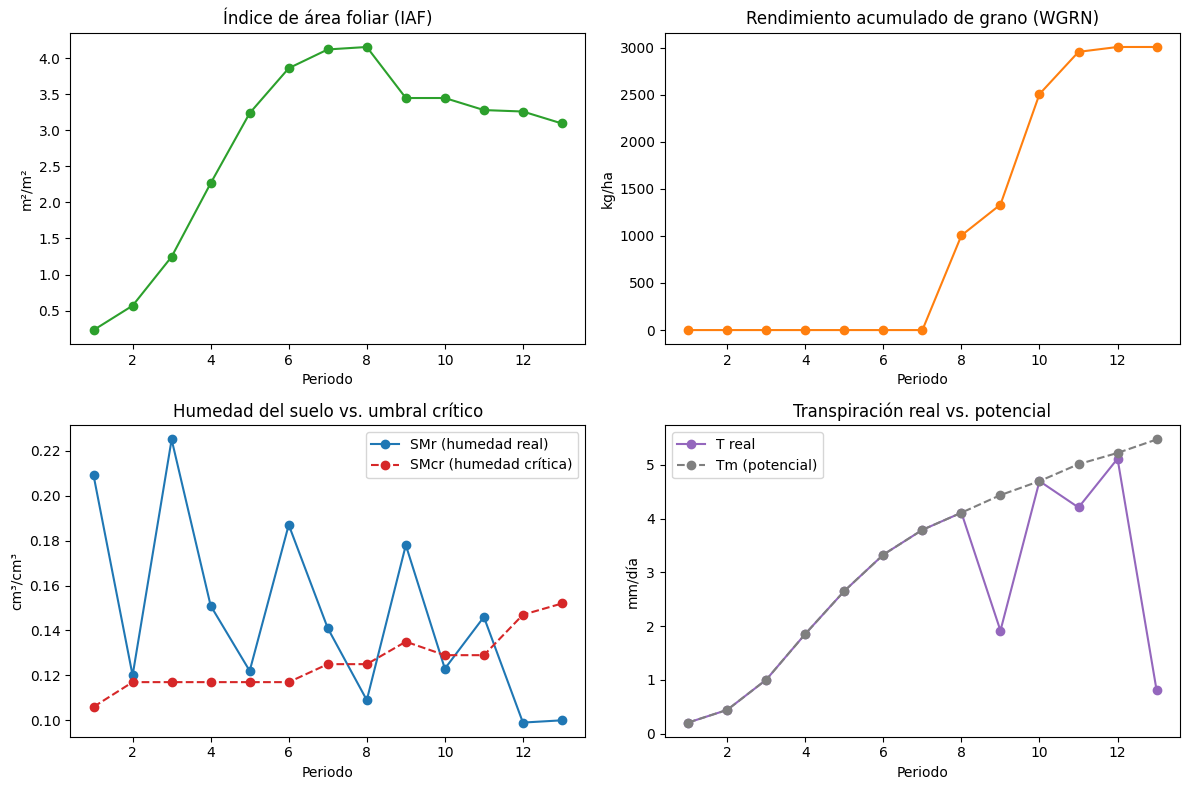

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(salida["Periodo"], salida["IAF"], "o-", color="tab:green")
axes[0,0].set_title("Índice de área foliar (IAF)")
axes[0,0].set_xlabel("Periodo"); axes[0,0].set_ylabel("m²/m²")

axes[0,1].plot(salida["Periodo"], salida["WGRN"], "o-", color="tab:orange")
axes[0,1].set_title("Rendimiento acumulado de grano (WGRN)")
axes[0,1].set_xlabel("Periodo"); axes[0,1].set_ylabel("kg/ha")

axes[1,0].plot(salida["Periodo"], salida["SMr"], "o-", label="SMr (humedad real)", color="tab:blue")
axes[1,0].plot(salida["Periodo"], salida["SMcr"], "o--", label="SMcr (humedad crítica)", color="tab:red")
axes[1,0].set_title("Humedad del suelo vs. umbral crítico")
axes[1,0].set_xlabel("Periodo"); axes[1,0].set_ylabel("cm³/cm³")
axes[1,0].legend()

axes[1,1].plot(salida["Periodo"], salida["T_real"], "o-", label="T real", color="tab:purple")
axes[1,1].plot(salida["Periodo"], salida["Tm"], "o--", label="Tm (potencial)", color="tab:gray")
axes[1,1].set_title("Transpiración real vs. potencial")
axes[1,1].set_xlabel("Periodo"); axes[1,1].set_ylabel("mm/día")
axes[1,1].legend()

plt.tight_layout()
plt.savefig("trayectorias_modelo.png", dpi=150)
plt.show()


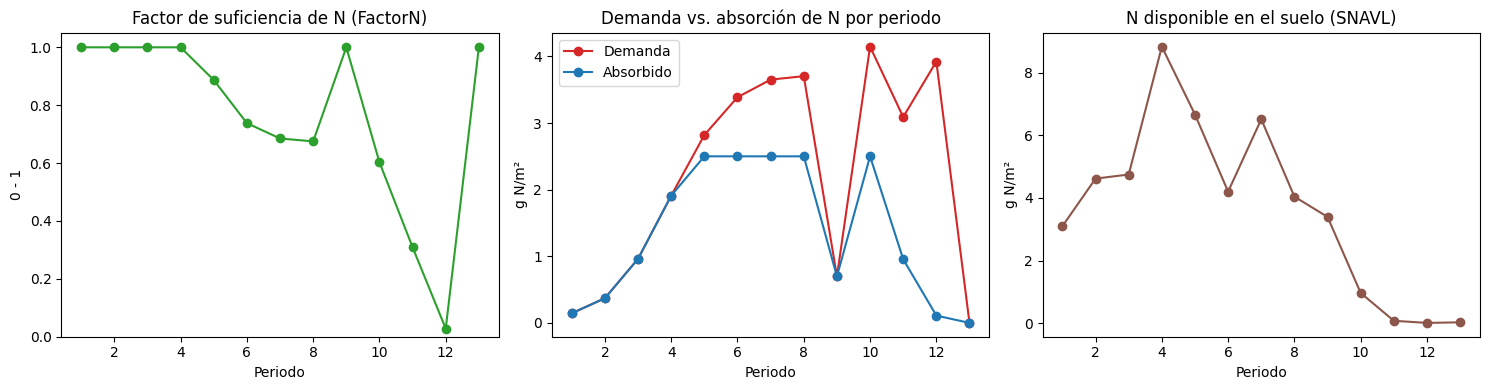

In [13]:
if simular_nitrogeno:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(salida["Periodo"], salida["FactorN"], "o-", color="tab:green")
    axes[0].set_title("Factor de suficiencia de N (FactorN)")
    axes[0].set_xlabel("Periodo"); axes[0].set_ylabel("0 - 1")
    axes[0].set_ylim(0, 1.05)

    axes[1].plot(salida["Periodo"], salida["N_demanda_gm2"], "o-", label="Demanda", color="tab:red")
    axes[1].plot(salida["Periodo"], salida["N_absorbido_gm2"], "o-", label="Absorbido", color="tab:blue")
    axes[1].set_title("Demanda vs. absorción de N por periodo")
    axes[1].set_xlabel("Periodo"); axes[1].set_ylabel("g N/m²")
    axes[1].legend()

    axes[2].plot(salida["Periodo"], salida["N_disponible_suelo_gm2"], "o-", color="tab:brown")
    axes[2].set_title("N disponible en el suelo (SNAVL)")
    axes[2].set_xlabel("Periodo"); axes[2].set_ylabel("g N/m²")

    plt.tight_layout()
    plt.savefig("trayectorias_nitrogeno.png", dpi=150)
    plt.show()
else:
    print("No hay simulación de N para graficar (falta la hoja 'Nitrogeno').")


## 9. Exploración interactiva (AFE)

In [14]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def plot_interactive_simulation(afe_value):
    plt.close('all')
    params = parametros.copy()
    params["AFE"] = afe_value

    try:
        salida_i, _ = simular(periodos, params, particion, rendimiento_esperado,
                               simular_nitrogeno=simular_nitrogeno,
                               parametros_n=parametros_n, aplicaciones_n=aplicaciones_n)
    except Exception as e:
        print(f"Error en la simulación: {e}")
        return

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"Simulación con AFE = {afe_value:.1f}", fontsize=14)

    axes[0, 0].plot(salida_i["Periodo"], salida_i["IAF"], "o-", color="tab:green")
    axes[0, 0].set_title("Índice de área foliar (IAF)")
    axes[0, 0].set_xlabel("Periodo"); axes[0, 0].set_ylabel("m²/m²")

    axes[0, 1].plot(salida_i["Periodo"], salida_i["WGRN"], "o-", color="tab:orange")
    axes[0, 1].set_title("Rendimiento acumulado de grano (WGRN)")
    axes[0, 1].set_xlabel("Periodo"); axes[0, 1].set_ylabel("kg/ha")

    axes[1, 0].plot(salida_i["Periodo"], salida_i["SMr"], "o-", label="SMr (real)", color="tab:blue")
    axes[1, 0].plot(salida_i["Periodo"], salida_i["SMcr"], "o--", label="SMcr (crítica)", color="tab:red")
    axes[1, 0].set_title("Humedad del suelo vs. umbral crítico")
    axes[1, 0].set_xlabel("Periodo"); axes[1, 0].set_ylabel("cm³/cm³")
    axes[1, 0].legend()

    axes[1, 1].plot(salida_i["Periodo"], salida_i["T_real"], "o-", label="T real", color="tab:purple")
    axes[1, 1].plot(salida_i["Periodo"], salida_i["Tm"], "o--", label="Tm (potencial)", color="tab:gray")
    axes[1, 1].set_title("Transpiración real vs. potencial")
    axes[1, 1].set_xlabel("Periodo"); axes[1, 1].set_ylabel("mm/día")
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

@widgets.interact(
    afe_value=widgets.FloatSlider(
        min=16, max=24, step=0.5,
        value=parametros["AFE"],
        description='AFE',
        continuous_update=False
    )
)
def interactive_plot(afe_value):
    plot_interactive_simulation(afe_value)


interactive(children=(FloatSlider(value=20.0, continuous_update=False, description='AFE', max=24.0, min=16.0, …

In [15]:
def plot_interactive_nitrogen_simulation(mxnup_value):
    """
    Ejecuta la simulación de nitrógeno con un nuevo MXNUP y muestra gráficas.

    Parámetros:
        mxnup_value (float): nuevo valor para la tasa máxima de absorción de N.
    """
    plt.close('all')  # Limpia figuras anteriores

    # Copiar ambos diccionarios para evitar mutaciones accidentales
    params_base = parametros.copy()
    params_n_copy = parametros_n.copy()
    params_n_copy["MXNUP"] = mxnup_value

    try:
        salida_n_i, _ = simular(
            periodos,
            params_base,                     # base parameters (copia)
            particion,
            rendimiento_esperado=rendimiento_esperado,
            simular_nitrogeno=True,
            parametros_n=params_n_copy,
            aplicaciones_n=aplicaciones_n
        )
    except Exception as e:
        print(f"Error en la simulación con MXNUP={mxnup_value}: {e}")
        return

    # Crear figura
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"Simulación con MXNUP = {mxnup_value:.2f} g N/m²/día", fontsize=14)

    # Gráfica 1: Factor de suficiencia de N
    axes[0].plot(salida_n_i["Periodo"], salida_n_i["FactorN"], "o-", color="tab:green")
    axes[0].set_title("Factor de suficiencia de N (FactorN)")
    axes[0].set_xlabel("Periodo")
    axes[0].set_ylabel("0 - 1")
    axes[0].set_ylim(0, 1.05)

    # Gráfica 2: Demanda vs. absorción
    axes[1].plot(salida_n_i["Periodo"], salida_n_i["N_demanda_gm2"], "o-", label="Demanda", color="tab:red")
    axes[1].plot(salida_n_i["Periodo"], salida_n_i["N_absorbido_gm2"], "o-", label="Absorbido", color="tab:blue")
    axes[1].set_title("Demanda vs. absorción de N por periodo")
    axes[1].set_xlabel("Periodo")
    axes[1].set_ylabel("g N/m²")
    axes[1].legend()

    # Gráfica 3: N disponible en el suelo
    axes[2].plot(salida_n_i["Periodo"], salida_n_i["N_disponible_suelo_gm2"], "o-", color="tab:brown")
    axes[2].set_title("N disponible en el suelo (SNAVL)")
    axes[2].set_xlabel("Periodo")
    axes[2].set_ylabel("g N/m²")

    plt.tight_layout()
    plt.show()  # o display(fig) si prefieres

# Crear el widget interactivo
@widgets.interact(
    mxnup_value=widgets.FloatSlider(
        min=0.1, max=1.0, step=0.05,
        value=parametros_n["MXNUP"],
        description='MXNUP',
        continuous_update=False
    )
)
def interactive_nitrogen_plot(mxnup_value):
    plot_interactive_nitrogen_simulation(mxnup_value)

interactive(children=(FloatSlider(value=0.25, continuous_update=False, description='MXNUP', max=1.0, min=0.1, …